# Binary Classification with CNNs: pneumonia_MNIST Data Set

## Setup

In [ ]:
# One-time setup: make the `visualization` helper importable, then fetch data +
# resolve paths. Each study's fetch logic lives in its own download_data.py.
import os
import sys

if "google.colab" in sys.modules:
    if not os.path.isdir("ConvolutedComputerVision"):
        !git clone -q https://github.com/samlowe106/ConvolutedComputerVision.git
    sys.path.insert(0, "ConvolutedComputerVision/src")

from visualization import colab_bootstrap

DATA_ROOT, CKPT_ROOT = colab_bootstrap(study="chest-x-ray-images-pneumonia")

In [1]:
import numpy as np
import tensorflow as tf


import datetime

notebook_start_time = datetime.datetime.now()

I0000 00:00:1782545089.820572  137597 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782545090.634148  137597 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
test_dir = f"{DATA_ROOT}/test"
train_dir = f"{DATA_ROOT}/train"
validation_dir = f"{DATA_ROOT}/val"

height, width, channels = 150, 150, 1

batch_size = 32

# While working, I discovered that the tf.keras.preprocessing.image.ImageDataGenerator class is deprecated
# using this new API instead

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="grayscale",
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="grayscale",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="grayscale",
    shuffle=False,
)

# because the outputs are batched, we have to concatenate all the batches
y_true = np.concatenate([y for x, y in test_ds], axis=0)

In [3]:
from visualization import class_weights, reset_keras, summary_graphics

In [ ]:
class_weight = class_weights(train_ds, cache_dir=DATA_ROOT)

print(f"Weight for normal class: {class_weight[0]:1.3f}")
print(f"Weight for pneumonia class: {class_weight[1]:1.3f}")

## Training

In [5]:
reset_keras()

epochs = 10
model_1 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="resizing"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(1000, activation="relu", name="5.2dense"),
        tf.keras.layers.Dense(500, activation="relu", name="5.4dense"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_1",
)

metrics = [
    tf.keras.metrics.TruePositives(name="tp"),
    tf.keras.metrics.TrueNegatives(name="tn"),
    tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
]

model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)


def make_callbacks(filepath):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=filepath, save_best_only=True, monitor="val_loss", mode="min"
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", mode="min", patience=5, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", mode="min", factor=0.5, patience=3
        ),
    ]


model_1.summary()

Model: "Model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.1flatten (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.2dense (Dense)                │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.4dense (Dense)                │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286,001 (4.91 MB)

 Trainable params: 1,286,001 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model_1.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks(
        os.path.join(CKPT_ROOT, "best_model_resizing_dense.keras")
    ),
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


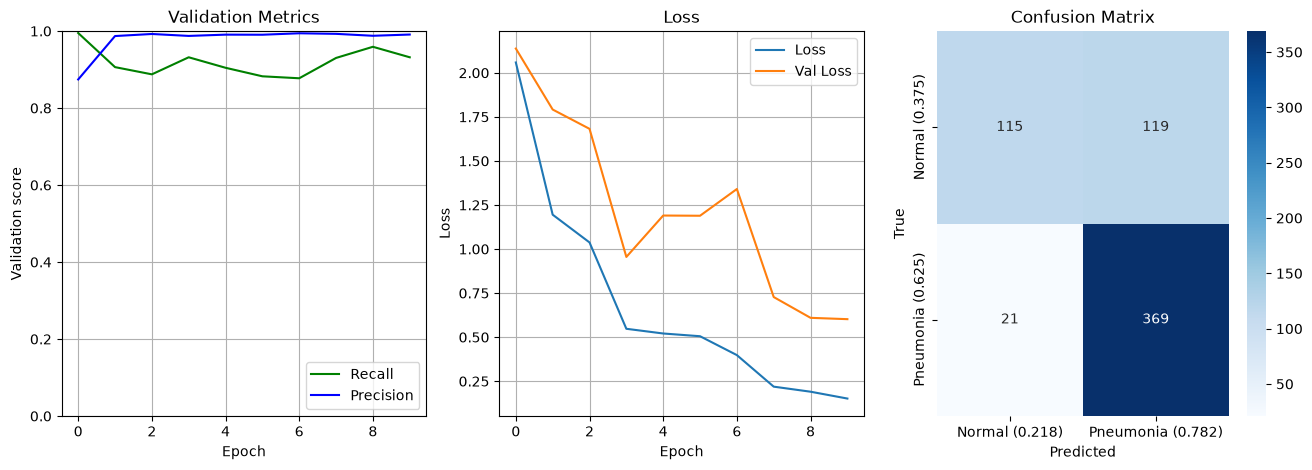

In [7]:
summary_graphics(history, model_1, test_ds)

In [ ]:
# load the best model
best_model = tf.keras.models.load_model(
    os.path.join(CKPT_ROOT, "best_model_resizing_dense.keras")
)
summary_graphics(history, best_model, test_ds)

In [9]:
reset_keras()

# try something similar to xception, but with fewer filters and layers
# to account for how small these images are
model_2 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="resizing"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            16, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            64, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(512, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.7, name="5.3dropout"),
        tf.keras.layers.Dense(256, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.5, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_2",
)

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

model_2.summary()

Model: "Model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 0.2rrot (RandomRotation)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 0.3rtran (RandomTranslation)    │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.1conv (Conv2D)                │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.2conv (Conv2D)                │ (None, 28, 28, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1.3pool (MaxPooling2D)          │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.1conv (Conv2D)                │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.2conv (Conv2D)                │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2.3pool (MaxPooling2D)          │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.1conv (SeparableConv2D)       │ (None, 7, 7, 64)       │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.2batchnorm                    │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.3conv (SeparableConv2D)       │ (None, 7, 7, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3.4pool (MaxPooling2D)          │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.1conv (SeparableConv2D)       │ (None, 4, 4, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.2batchnorm                    │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.3conv (SeparableConv2D)       │ (None, 4, 4, 64)       │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4.6pool (MaxPooling2D)          │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.1flatten (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.2dense (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.3dropout (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.4dense (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5.5dropout (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           25

 Total params: 296,657 (1.13 MB)

 Trainable params: 296,401 (1.13 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
history = model_2.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks(os.path.join(CKPT_ROOT, "best_model_resizing_2.keras")),
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


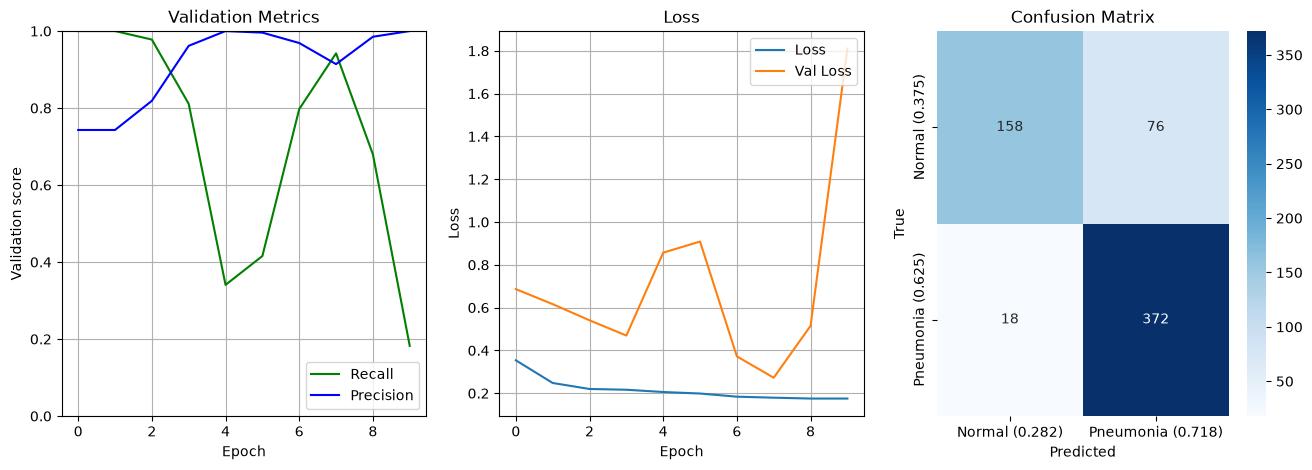

In [11]:
summary_graphics(history, model_2, test_ds)

In [12]:
reset_keras()

# unlike with the MNIST dataset, this model is not overfitting
# let's up the number of neurons
model_3 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="resizing"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="1.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            64, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.Conv2D(
            64, (3, 3), activation="relu", padding="same", name="2.2conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.3pool"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.4pool"),
        tf.keras.layers.SeparableConv2D(
            256, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            256, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.6pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(512, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.5, name="5.3dropout"),
        tf.keras.layers.Dense(256, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.4, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_3",
)

model_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

In [ ]:
history = model_3.fit(
    train_ds,
    validation_data=validation_ds,
    batch_size=batch_size,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks(os.path.join(CKPT_ROOT, "best_model_resizing_3.keras")),
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


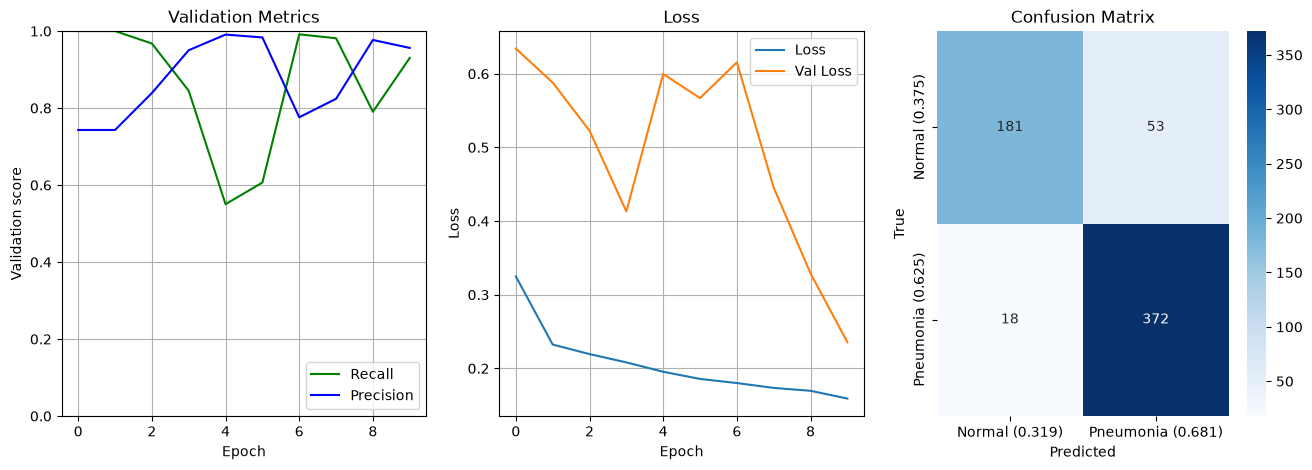

In [14]:
summary_graphics(history, model_3, test_ds)

In [15]:
reset_keras()

# let's increase dropout, add more batch normalization, and add more epochs
epochs = 20
model_4 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="resizing"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="1.2batchnorm"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="1.3conv"
        ),
        tf.keras.layers.BatchNormalization(name="1.4batchnorm"),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            64, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="2.2batchnorm"),
        tf.keras.layers.Conv2D(
            64, (3, 3), activation="relu", padding="same", name="2.3conv"
        ),
        tf.keras.layers.BatchNormalization(name="2.4batchnorm"),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.5pool"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.4batchnorm"),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.5pool"),
        tf.keras.layers.SeparableConv2D(
            256, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            256, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.4batchnorm"),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.5pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(512, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.7, name="5.3dropout"),
        tf.keras.layers.Dense(256, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.5, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_4",
)

model_4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

In [ ]:
history = model_4.fit(
    train_ds,
    validation_data=validation_ds,
    batch_size=batch_size,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks(os.path.join(CKPT_ROOT, "best_model_resizing_4.keras")),
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


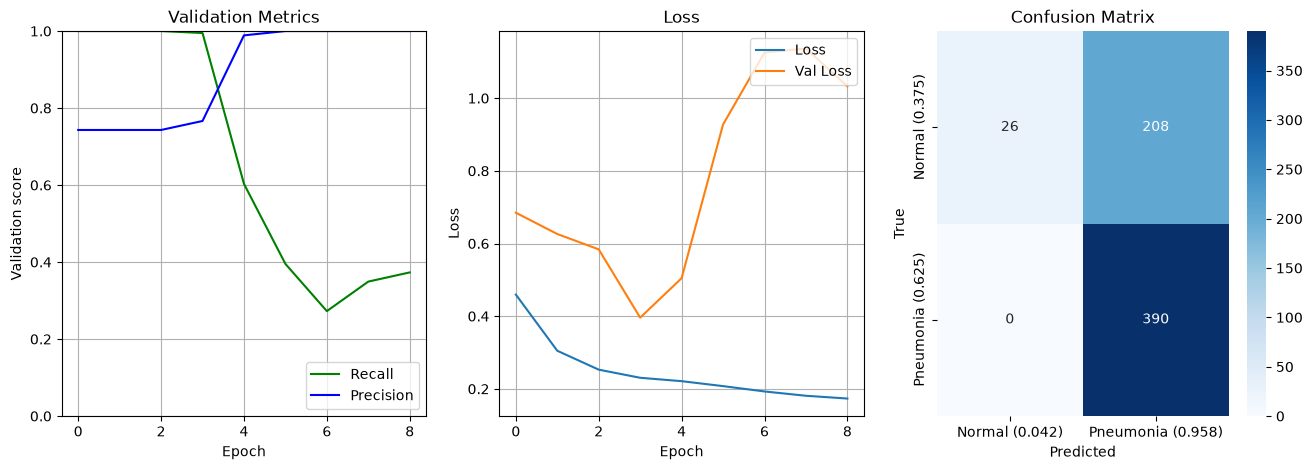

In [17]:
summary_graphics(history, model_4, test_ds)

In [18]:
reset_keras()

# add more convolutional layers and neurons to the dense layers
model_5 = tf.keras.models.Sequential(
    [
        tf.keras.layers.InputLayer((150, 150, 1), name="input"),
        tf.keras.layers.Resizing(28, 28, name="resizing"),
        # tf.keras.layers.RandomFlip("horizontal", name="0.1rflip"),
        tf.keras.layers.RandomRotation(0.2, name="0.2rrot"),
        tf.keras.layers.RandomTranslation(0.2, 0.2, name="0.3rtran"),
        # tf.keras.layers.RandomZoom(0.2, name="0.4rzoom"),
        tf.keras.layers.Rescaling(1.0 / 255, name="rescale"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="1.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="1.2batchnorm"),
        tf.keras.layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", name="1.3conv"
        ),
        tf.keras.layers.BatchNormalization(name="1.4batchnorm"),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="1.3pool"),
        tf.keras.layers.Conv2D(
            64, (3, 3), activation="relu", padding="same", name="2.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="2.2batchnorm"),
        tf.keras.layers.Conv2D(
            64, (3, 3), activation="relu", padding="same", name="2.3conv"
        ),
        tf.keras.layers.BatchNormalization(name="2.4batchnorm"),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="2.5pool"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="3.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="3.3conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.4batchnorm"),
        tf.keras.layers.SeparableConv2D(
            128, (3, 3), activation="relu", padding="same", name="3.5conv"
        ),
        tf.keras.layers.BatchNormalization(name="3.6batchnorm"),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="3.7pool"),
        tf.keras.layers.SeparableConv2D(
            256, (3, 3), activation="relu", padding="same", name="4.1conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.2batchnorm"),
        tf.keras.layers.SeparableConv2D(
            256, (3, 3), activation="relu", padding="same", name="4.3conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.4batchnorm"),
        tf.keras.layers.SeparableConv2D(
            256, (3, 3), activation="relu", padding="same", name="4.5conv"
        ),
        tf.keras.layers.BatchNormalization(name="4.6batchnorm"),
        tf.keras.layers.MaxPooling2D((2, 2), padding="same", name="4.5pool"),
        tf.keras.layers.Flatten(name="5.1flatten"),
        tf.keras.layers.Dense(1024, activation="relu", name="5.2dense"),
        tf.keras.layers.Dropout(0.7, name="5.3dropout"),
        tf.keras.layers.Dense(512, activation="relu", name="5.4dense"),
        tf.keras.layers.Dropout(0.5, name="5.5dropout"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
    ],
    name="Model_5",
)

model_5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

In [ ]:
history = model_5.fit(
    train_ds,
    validation_data=validation_ds,
    batch_size=batch_size,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks(os.path.join(CKPT_ROOT, "best_model_resizing_5.keras")),
)
summary_graphics(history, model_5, test_ds)

In [ ]:
notebook_end_time = datetime.datetime.now()
print(
    f"Notebook last run (end-to-end): {notebook_end_time} (duration: {notebook_end_time - notebook_start_time})"
)

Notebook last run (end-to-end): 2026-06-27 03:34:18.070402 (duration: 0:09:26.394293)


: 